In [12]:

import numpy as np
import uaibot as ub

#Define the following problem
#min_u  u_1^2 + u_2^2 + 3u_3^2 + u_1*u_2 + 2u_1
# subject to
# 4u1+2u2+u3 >=1 
# u2 <= 0.3  ---> -u2 >= -0.3
#
#To use "solve_qp", the problem should be written as
# min_u 0.5*u^T*H*u + f^T*u
# such that A*u >= b


H = 2*np.matrix([[1.0,0.5,0.0],[0.5,1.0,0.0],[0.0,0.0,3.0]])
f = np.matrix([2.0,0.0,0.0]).T
A = np.matrix([[4.0,2.0,1.0],[0.0,-1.0,0.0]])
b = np.matrix([1.0,-0.3]).T

print("H = \n", H)
print("f = \n", f)
print("A = \n", A)
print("b = \n", b)


H = 
 [[2. 1. 0.]
 [1. 2. 0.]
 [0. 0. 6.]]
f = 
 [[2.]
 [0.]
 [0.]]
A = 
 [[ 4.  2.  1.]
 [ 0. -1.  0.]]
b = 
 [[ 1. ]
 [-0.3]]


In [13]:
u = ub.Utils.solve_qp(H, f, A, b)

print("u = "+str(u.T)+"^T")


u = [[0.0745 0.3    0.102 ]]^T


In [9]:
#We can also add equality constraints. Lets say u1+u2 = 0

A_eq = np.matrix([1.0,1.0,0.])
b_eq = np.matrix([0.])

u = ub.Utils.solve_qp(H, f, A, b, A_eq, b_eq)

print("u = "+str(u.T)+"^T")

u = [[ 0.3846 -0.3846  0.2308]]^T


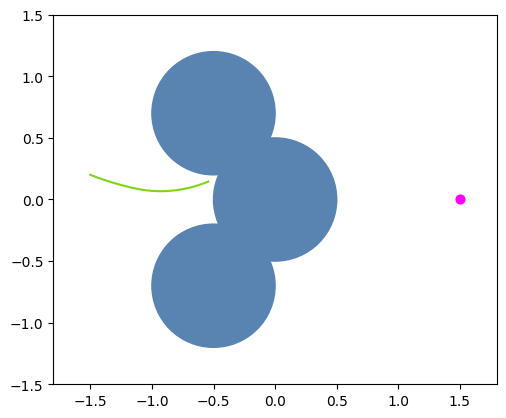

In [14]:

import numpy as np
import matplotlib.pyplot as plt
import uaibot as ub
import matplotlib.patches as patches

#Parameters
kp = 0.5
eta = 0.3
dt = 0.01
tmax = 15
delta = 0.05
eps = 0.01
qF = np.matrix([1.5,0]).T
q0 = np.matrix([-1.5,0.2]).T
centers = [np.matrix([-0.5,0.7]).T, np.matrix([-0.5,-0.7]).T , np.matrix([0.0,0.0]).T]
radius = [0.5,0.5,0.5]

#Start simulation
q = q0
hist_q = []

for i in range(round(tmax/dt)):


    hist_q.append(np.matrix(q))
    
    #Assembly the CBF controller
    H = 2*(1+eps)*np.matrix([[1.0,0.0],[0.0,1.0]])
    f = 2*kp*(q-qF)
    
    A = np.matrix(np.zeros((0,2)))
    b = np.matrix(np.zeros((0,1)))
    
    for k in range(len(centers)):
        B_k_fun_ = np.linalg.norm(q-centers[k])-radius[k]-delta
        grad_B_k_fun = (q-centers[k]).T/np.linalg.norm(q-centers[k])

        A = np.vstack( (A,  grad_B_k_fun) )
        b = np.vstack( (b,  -eta * B_k_fun_) )
        

    #Compute the control input
    u = ub.Utils.solve_qp(H,f,A,b)
    
    #Integrate the equation \dot{q} = u(q)
    q+= u*dt
 
#Plot image
fig, ax = plt.subplots()
ax.set_aspect('equal')
ax.plot([q[0, 0] for q in hist_q], [q[1, 0] for q in hist_q], color='#81d41a')
ax.scatter([qF[0,0]],[qF[1,0]], color='magenta',s=40)

for i in range(len(centers)):
    circle = patches.Circle((centers[i][0], centers[i][1]), radius=radius[i], color='#5983b0')  
    ax.add_patch(circle)
    
    
ax.set_xlim(-1.8, 1.8)
ax.set_ylim(-1.5, 1.5)

plt.show()



PERTURBATION MODE


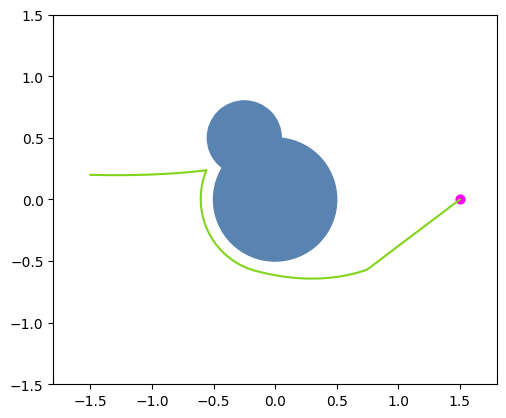

In [17]:

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import uaibot as ub

#Parameters
kp = 0.5
eta = 0.3
dt = 0.01
tmax = 60
delta = 0.05
eps = 0.01
qF = np.matrix([1.5,0]).T
q0 = np.matrix([-1.5,0.2]).T
centers = [np.matrix([-0.25,0.5]).T , np.matrix([0.0,0.0]).T]
radius = [0.3,0.5]

#Parameters for perturbation
last_T = 50
tol_stuck = 0.01
decay_rate = 0.99
perturb_norm = 3.0
min_perturb_norm = 0.3
min_error_start_perturb = 0.05

#Start simulation
q = q0
hist_q = []
hist_e = []
perturbation = np.matrix([0.,0.]).T
perturbation_mode = False

for i in range(round(tmax/dt)):


    hist_q.append(np.matrix(q))
    hist_e.append(np.linalg.norm(q-qF))

    #Lets verify if it got stuck
    if i>last_T and hist_e[-1] > min_error_start_perturb and not perturbation_mode:
        recent = hist_e[-last_T:]
        max_diff = max(recent) - min(recent)
        # print(max_diff)
        if max_diff < tol_stuck:
            perturbation =  np.matrix(np.random.randn(2,1))
            perturbation = perturb_norm * perturbation/np.linalg.norm(perturbation)
            #Set the status to "perturbation mode"
            perturbation_mode = True
            print("PERTURBATION MODE")
    
    #While at "perturbation_mode", decay the perturbation
    #to zero exponentially
    if perturbation_mode:
        # print(perturbation.T)
        perturbation = decay_rate*perturbation
        if np.linalg.norm(perturbation)<=min_perturb_norm:
            perturbation = np.matrix(np.zeros((2,1)))
            perturbation_mode = False     

    #Assembly the CBF controller
    H = 2*(1+eps)*np.matrix([[1.0,0.0],[0.0,1.0]])
    
    
    f = 2*kp*(q-qF) +perturbation
    # if not perturbation_mode:
    #     f = 2*kp*(q-qF) +perturbation
    # else:
    #     f = perturbation
    
    A = np.matrix(np.zeros((0,2)))
    b = np.matrix(np.zeros((0,1)))
    
    for k in range(len(centers)):
        B_k_fun_ = np.linalg.norm(q-centers[k])-radius[k]-delta
        grad_B_k_fun = (q-centers[k]).T/np.linalg.norm(q-centers[k])

        A = np.vstack( (A,  grad_B_k_fun) )
        b = np.vstack( (b,  -eta * B_k_fun_) )
        

    #Compute the control input
    u = ub.Utils.solve_qp(H,f,A,b)
    
    #Integrate the equation \dot{q} = u(q)
    q+= u*dt
    

#Plot image
fig, ax = plt.subplots()
ax.set_aspect('equal')
ax.plot([q[0, 0] for q in hist_q], [q[1, 0] for q in hist_q], color='#81d41a')
ax.scatter([qF[0,0]],[qF[1,0]], color='magenta',s=40)

for i in range(len(centers)):
    circle = patches.Circle((centers[i][0], centers[i][1]), radius=radius[i], color='#5983b0')  
    ax.add_patch(circle)
    
    
ax.set_xlim(-1.8, 1.8)
ax.set_ylim(-1.5, 1.5)

plt.show()

